# Conditional Distributions

So previously we looked at Marginal distributions. Essentially we take a slice of y and add up all the x values for every y and then plot it. A conditional distribution, is a distribution of y given we know what x is. Similarily we are taking into consieration **one** axis of our join distribution and then we are making that into a probability by dividing it by something to **renormalize** it.

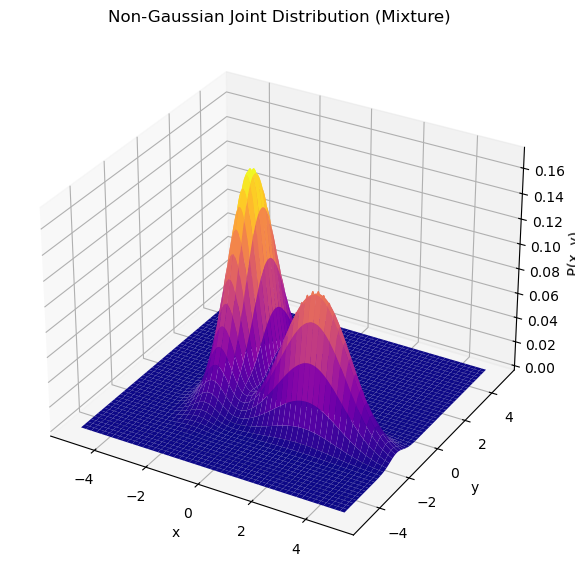

In [2]:
## first step is to create our joint distribution

import numpy as np
import matplotlib.pyplot as plt

# ---- Grid ----
x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)
X, Y = np.meshgrid(x, y)

# ---- Define two non-Gaussian blobs ----
# Blob 1: narrow in x, wide in y, tilted
Z1 = np.exp(
    -((X + 1.5)**2) / 0.5
    -((Y - 1.0 - 0.5 * X)**2) / 2.5
)

# Blob 2: wide in x, narrow in y
Z2 = np.exp(
    -((X - 2.0)**2) / 3.0
    -((Y + 1.5)**2) / 0.4
)

# ---- Mixture ----
Z = 0.6 * Z1 + 0.4 * Z2

# ---- Normalize to make it a valid joint distribution ----
dx = x[1] - x[0]
dy = y[1] - y[0]
Z /= Z.sum() * dx * dy   # now ∫∫ P(x,y) dx dy = 1

# ---- Plot 3D surface ----
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X, Y, Z,
    cmap="plasma",
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("P(x, y)")
ax.set_title("Non-Gaussian Joint Distribution (Mixture)")

plt.show()


## Next we are going to take a slice of our joint probability distribution



In [24]:
np.random.seed(123)
index = np.random.randint(0, len(y))

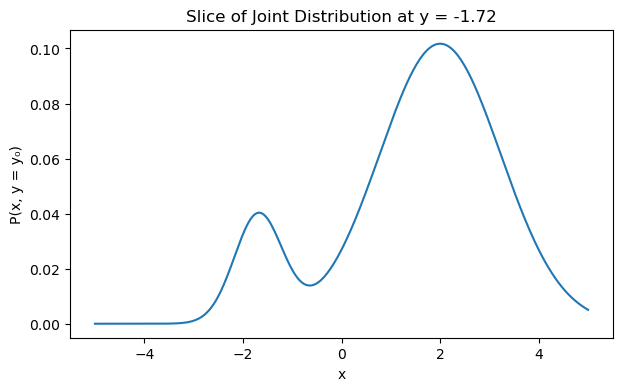

In [25]:
x_slice = X[index, :]# all x at fixed y
z_slice = Z[index, :]# pdf values at that y
y_value = y[index]


plt.figure(figsize=(7, 4))
plt.plot(x_slice, z_slice)
plt.xlabel("x")
plt.ylabel("P(x, y = y₀)")
plt.title(f"Slice of Joint Distribution at y = {y_value:.2f}")
plt.show()


This looks like a probability distribution but the area under the curve doesn't add up to one. This because in the context of the joint distribution there is nothing that says it has to add up to one. We know that all the probability values have to but not just one slice. 

So we need to transform this into a probability distribution. So we will take each probability and divide it but the total of all the sum of the probability values in this slice

Area under slice: 0.3581488357674841
Area under conditional: 0.9999999999999998


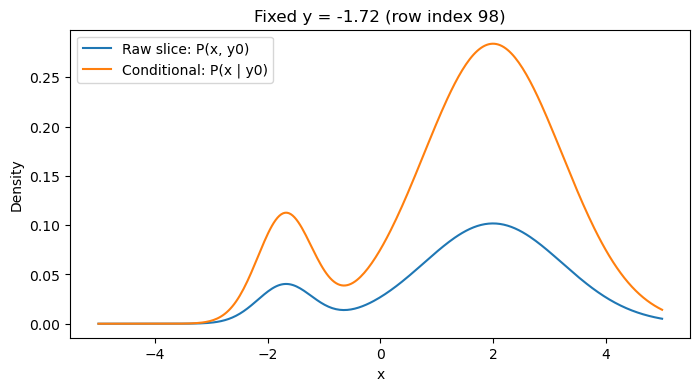

In [26]:
# Area under the raw slice (should NOT be 1)
area = 0.0
for i in range(len(x_slice)):
    area += z_slice[i] * dx

print("Area under slice:", area)

# Conditional distribution p(x | y = y_value)
p_x_given_y = np.zeros_like(z_slice)
for i in range(len(z_slice)):
    p_x_given_y[i] = z_slice[i] / area

# Verify area is ~1
area_cond = 0.0
for i in range(len(x_slice)):
    area_cond += p_x_given_y[i] * dx

print("Area under conditional:", area_cond)

# Plot
plt.figure(figsize=(8,4))
plt.plot(x_slice, z_slice, label="Raw slice: P(x, y0)")
plt.plot(x_slice, p_x_given_y, label="Conditional: P(x | y0)")
plt.xlabel("x")
plt.ylabel("Density")
plt.title(f"Fixed y = {y_value:.2f} (row index {index})")
plt.legend()
plt.show()


Check: ∫ p_X(x) dx ≈ 0.9999999999999998
Check: ∫ p_Y(y) dy ≈ 1.0
Check: ∫∫ Z_indep dx dy ≈ 0.9999999999999998


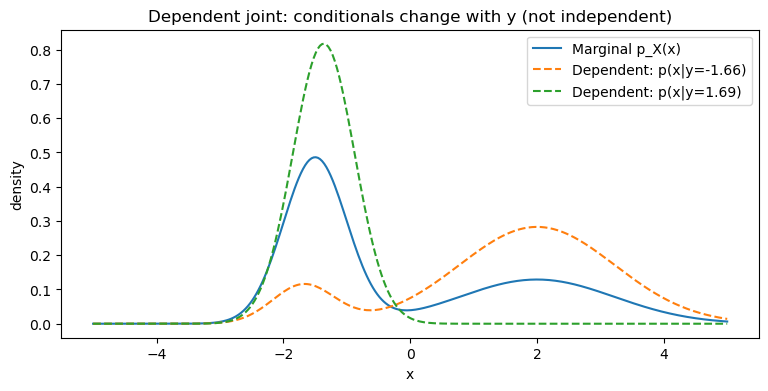

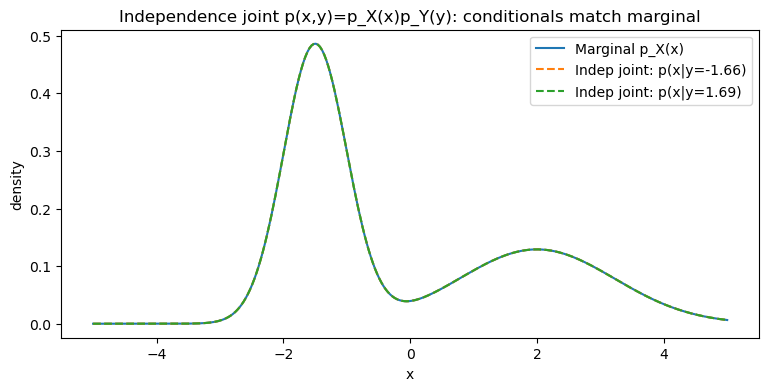

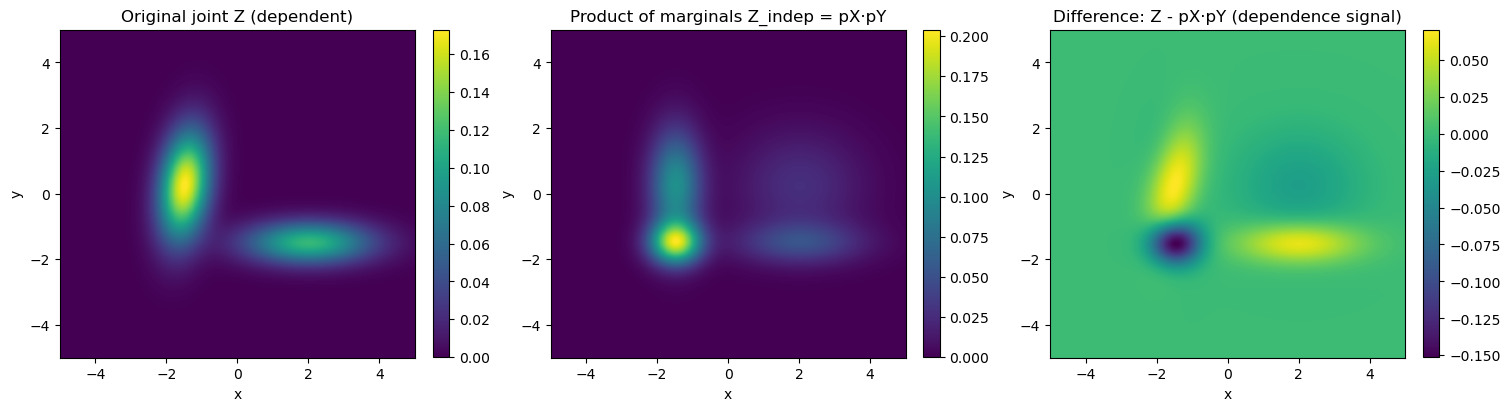

Max |p(x|y)-p(x)| for dependent joint (should be noticeably > 0): 0.5718278496441856
Max |p(x|y)-p(x)| for indep joint (should be ~0):               1.6653345369377348e-16


In [27]:


# ---------- 1) Compute marginals from the joint ----------
# Z has shape (len(y), len(x)) because meshgrid(x, y) creates rows for y and cols for x.
p_x = Z.sum(axis=0) * dy   # integrate out y  -> p_X(x)
p_y = Z.sum(axis=1) * dx   # integrate out x  -> p_Y(y)

print("Check: ∫ p_X(x) dx ≈", p_x.sum() * dx)
print("Check: ∫ p_Y(y) dy ≈", p_y.sum() * dy)

# ---------- 2) Build the 'independence' joint: p_X(x) p_Y(y) ----------
Z_indep = np.outer(p_y, p_x)  # shape (len(y), len(x))

print("Check: ∫∫ Z_indep dx dy ≈", Z_indep.sum() * dx * dy)

# ---------- 3) Pick a y-slice and compare conditional vs marginal ----------
# Helper: conditional p(x|y=y_idx) from a joint surface
def conditional_x_given_y(joint_Z, y_idx):
    z_slice = joint_Z[y_idx, :]                 # joint slice at fixed y
    area = z_slice.sum() * dx                   # ∫ P(x, y0) dx = p_Y(y0)
    return z_slice / area                       # normalize -> p(x|y0)

# choose 2 different y rows to show whether conditioning changes anything
y_idx1 = len(y) // 3
y_idx2 = 2 * len(y) // 3

cond_dep_1 = conditional_x_given_y(Z, y_idx1)
cond_dep_2 = conditional_x_given_y(Z, y_idx2)

cond_ind_1 = conditional_x_given_y(Z_indep, y_idx1)
cond_ind_2 = conditional_x_given_y(Z_indep, y_idx2)

# ---------- 4) Plot: conditional vs marginal (dependent joint) ----------
plt.figure(figsize=(9,4))
plt.plot(x, p_x, label="Marginal p_X(x)")
plt.plot(x, cond_dep_1, "--", label=f"Dependent: p(x|y={y[y_idx1]:.2f})")
plt.plot(x, cond_dep_2, "--", label=f"Dependent: p(x|y={y[y_idx2]:.2f})")
plt.title("Dependent joint: conditionals change with y (not independent)")
plt.xlabel("x"); plt.ylabel("density")
plt.legend()
plt.show()

# ---------- 5) Plot: conditional vs marginal (independence-constructed joint) ----------
plt.figure(figsize=(9,4))
plt.plot(x, p_x, label="Marginal p_X(x)")
plt.plot(x, cond_ind_1, "--", label=f"Indep joint: p(x|y={y[y_idx1]:.2f})")
plt.plot(x, cond_ind_2, "--", label=f"Indep joint: p(x|y={y[y_idx2]:.2f})")
plt.title("Independence joint p(x,y)=p_X(x)p_Y(y): conditionals match marginal")
plt.xlabel("x"); plt.ylabel("density")
plt.legend()
plt.show()

# ---------- 6) Show factorization visually with heatmaps ----------
# If independent, Z_indep should look like a "separable" pattern (no tilt/ridges).
fig, axs = plt.subplots(1, 3, figsize=(15,4), constrained_layout=True)

im0 = axs[0].imshow(Z, origin="lower",
                    extent=[x.min(), x.max(), y.min(), y.max()],
                    aspect="auto")
axs[0].set_title("Original joint Z (dependent)")
axs[0].set_xlabel("x"); axs[0].set_ylabel("y")
plt.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(Z_indep, origin="lower",
                    extent=[x.min(), x.max(), y.min(), y.max()],
                    aspect="auto")
axs[1].set_title("Product of marginals Z_indep = pX·pY")
axs[1].set_xlabel("x"); axs[1].set_ylabel("y")
plt.colorbar(im1, ax=axs[1], fraction=0.046)

diff = Z - Z_indep
im2 = axs[2].imshow(diff, origin="lower",
                    extent=[x.min(), x.max(), y.min(), y.max()],
                    aspect="auto")
axs[2].set_title("Difference: Z - pX·pY (dependence signal)")
axs[2].set_xlabel("x"); axs[2].set_ylabel("y")
plt.colorbar(im2, ax=axs[2], fraction=0.046)

plt.show()

# ---------- 7) Numeric check of the slide statement ----------
# For independence: p(x|y) == p(x) for all y (approximately on grid).
# Let's quantify the max absolute difference across a few y values.
test_rows = np.linspace(0, len(y)-1, 8, dtype=int)

max_diff_dep = 0.0
max_diff_ind = 0.0
for yi in test_rows:
    max_diff_dep = max(max_diff_dep, np.max(np.abs(conditional_x_given_y(Z, yi) - p_x)))
    max_diff_ind = max(max_diff_ind, np.max(np.abs(conditional_x_given_y(Z_indep, yi) - p_x)))

print("Max |p(x|y)-p(x)| for dependent joint (should be noticeably > 0):", max_diff_dep)
print("Max |p(x|y)-p(x)| for indep joint (should be ~0):              ", max_diff_ind)
